# OND trigger design : per-river top-third calibration

Trigger spec (working group, 29 Sep 2026):
- WHERE: the river basin / zone pairs the EDRMC Bega flood alert lists as at risk
  of riverine flooding: Wabi Shebelle (Shebelle zone) | Genale Dawa (Afder, Liben,
  Dawa) | lower Omo Gibe (South Omo) | Bilate (Sidama, West Guji) | Kulfo, Slena
  and Sego (Gamo) | Akobo (Agnewak) | Baro (Itang, Nuwer, Agnewak).
- WHEN: OND only (October to December).
- SHAPE: one trigger across all areas; RANKING PER RIVER (working group: not a
  national ranking). For each river, its own OND seasons 2003 to 2025 are ranked
  by the river's seasonal peak; the threshold is set at the level of its
  3rd-largest season, so a river crossing is a 1-in-8 event for that river.
- Trigger: reached when any river is at or over its threshold. The top-3 depth
  was chosen so the OVERALL (any-river) frequency lands on the 1-in-3 spec:
  ranking each river's top third instead gives a union of 18 activations in 23
  years (1-in-1.3), which the working group rejected against the spec; the
  alternatives considered are in processed/comparison/ond_trigger_sweep notes
  (any river top 4: 1-in-2.4 | 3 of 7 rivers in their top third: 1-in-2.4 |
  4 of 7: 1-in-4.0).

Method detail: a river's season statistic is the maximum over its stations of
(the station's OND daily maximum in that season / the station's median OND
seasonal maximum). Ranking this normalised statistic lets stations of very
different size (Dolow ~1800 m3/s, Webe Gestro ~200) carry equal weight inside
one river system. The river's threshold ratio is its 8th-largest season
statistic; each station's threshold in m3/s is that ratio times the station's
median OND seasonal maximum. Crossing any station threshold is then exactly
equivalent to the river's season entering its own top third.

Record: GloFAS v4 reanalysis (the version the operational forecast runs),
channel-snapped cells, OND 2003 to 2025.

Coverage notes, stated for the record: the Kulfo, Slena and Sego at Arba Minch
are below GloFAS's 0.05 degree resolution; the Gamo station is the Abaya-Chamo
lake system cell and is labelled as such. The Dawa is monitored by a dedicated
cell in Daawa zone; Dolow sits below the Genale-Dawa confluence.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import ocha_stratus as stratus
import pandas as pd

STAGE = "dev"
PROJECT_PREFIX = "ds-aa-eth-flooding"
OND = [10, 11, 12]
YEARS = list(range(2003, 2026))
N_YEARS = len(YEARS)
TOP_N = 3  # per-river depth; chosen so the any-river union is 1-in-3 overall

RIVER_OF = {
    "station_1": "Wabi Shebelle", "station_2": "Wabi Shebelle", "station_3": "Wabi Shebelle",
    "station_4": "Wabi Shebelle", "G1904": "Wabi Shebelle",
    "RP_4045_0535": "Genale Dawa", "RP_4205_0415": "Genale Dawa",
    "station_5": "Genale Dawa", "dawa_1": "Genale Dawa",
    "omo_1": "Omo", "bilate_1": "Bilate", "gamo_1": "Gamo lakes",
    "baro_1": "Baro", "akobo_1": "Akobo",
}
RIVERS = ["Wabi Shebelle", "Genale Dawa", "Omo", "Bilate", "Gamo lakes", "Baro", "Akobo"]

## Load the OND reanalysis, all 14 stations

In [2]:
frames = []
for blob in ["glofas_discharge.parquet", "glofas_discharge_reporting_points.parquet"]:
    df = stratus.load_parquet_from_blob(f"{PROJECT_PREFIX}/processed/glofas/{blob}", stage=STAGE)
    df = df[df["dataset"] == "reanalysis"]
    frames.append(df[["station_id", "valid_time", "discharge"]])
nb_ = stratus.load_parquet_from_blob(
    f"{PROJECT_PREFIX}/processed/glofas/glofas_discharge_newbasins_ond.parquet", stage=STAGE
)
frames.append(nb_[["station_id", "valid_time", "discharge"]])
rean = pd.concat(frames, ignore_index=True)
rean["valid_time"] = pd.to_datetime(rean["valid_time"]).dt.normalize()
rean["date"] = rean["valid_time"] - pd.Timedelta(days=1)
rean = rean.sort_values("valid_time").drop_duplicates(["station_id", "date"], keep="last")
ond = rean[rean["date"].dt.month.isin(OND) & rean["date"].dt.year.isin(YEARS)]
daily = ond.pivot_table(index="date", columns="station_id", values="discharge")
print(daily.shape, "|", sorted(daily.columns))

(2116, 14) | ['G1904', 'RP_4045_0535', 'RP_4205_0415', 'akobo_1', 'baro_1', 'bilate_1', 'dawa_1', 'gamo_1', 'omo_1', 'station_1', 'station_2', 'station_3', 'station_4', 'station_5']


## Per-river season statistic and thresholds

In [3]:
seas_max = daily.groupby(daily.index.year).max()          # station OND max per season
med_max = seas_max.median()                                # station median OND seasonal max
norm = seas_max / med_max                                  # normalised seasonal peaks

river_stat = pd.DataFrame({
    r: norm[[s for s, rr in RIVER_OF.items() if rr == r and s in norm.columns]].max(axis=1)
    for r in RIVERS
})
ratio_star = river_stat.apply(lambda col: col.sort_values(ascending=False).iloc[TOP_N - 1])
print("threshold ratio per river (3rd-largest normalised seasonal peak):")
print(ratio_star.round(2).to_string())

levels = pd.DataFrame({
    "station_id": med_max.index,
    "river": [RIVER_OF[s] for s in med_max.index],
    "median_ond_max_m3s": med_max.round(1).values,
}).set_index("station_id")
levels["threshold_m3s"] = (med_max * levels["river"].map(ratio_star)).round(1)
levels.sort_values(["river", "station_id"])

threshold ratio per river (3rd-largest normalised seasonal peak):
Wabi Shebelle    1.23
Genale Dawa      1.51
Omo              1.27
Bilate           1.53
Gamo lakes       1.53
Baro             1.26
Akobo            1.29


,river,median_ond_max_m3s,threshold_m3s
station_id,,,
akobo_1,Akobo,284.899994,367.700012
baro_1,Baro,1601.000000,2015.699951
bilate_1,Bilate,142.100006,217.199997
gamo_1,Gamo lakes,461.600006,706.500000
RP_4045_0535,Genale Dawa,526.900024,796.599976
RP_4205_0415,Genale Dawa,1558.500000,2356.600098
dawa_1,Genale Dawa,279.700012,422.899994
station_5,Genale Dawa,193.199997,292.100006
omo_1,Omo,3806.399902,4830.000000


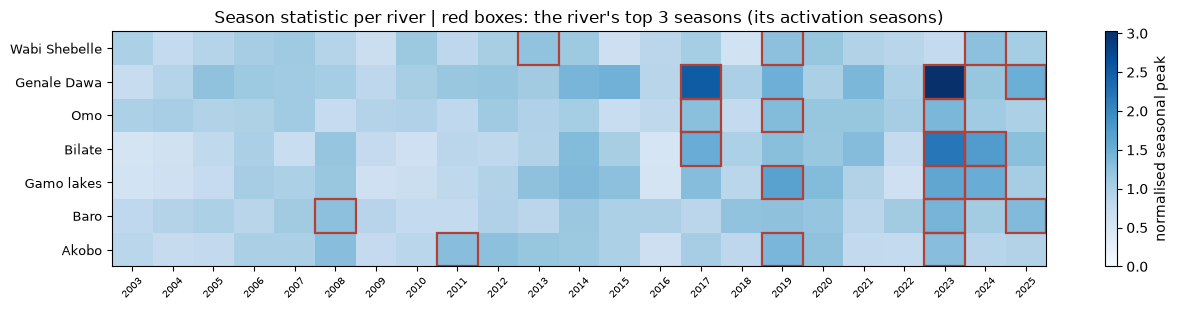

In [4]:
fig, ax = plt.subplots(figsize=(13, 3.2))
im = ax.imshow(river_stat.T.values, cmap="Blues", aspect="auto",
               vmin=0, vmax=float(river_stat.max().max()))
for i, r in enumerate(RIVERS):
    thr_r = ratio_star[r]
    for j, y in enumerate(YEARS):
        if river_stat.loc[y, r] >= thr_r:
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False,
                                       edgecolor="#B34036", linewidth=1.6))
ax.set_xticks(range(N_YEARS)); ax.set_xticklabels(YEARS, fontsize=7, rotation=45)
ax.set_yticks(range(len(RIVERS))); ax.set_yticklabels(RIVERS, fontsize=9)
plt.colorbar(im, ax=ax, label="normalised seasonal peak")
ax.set_title("Season statistic per river | red boxes: the river's top 3 seasons (its activation seasons)")
plt.tight_layout(); plt.show()

## The trigger: any river in its own top 3 seasons

Per-river individual RP = (23+1)/3 = 8.0 by construction. The overall (union)
frequency is measured below; the top-3 depth was selected to land it on the
1-in-3 spec.

In [5]:
active = river_stat.ge(ratio_star, axis=1)
union_years = active.index[active.any(axis=1)].tolist()
m = len(union_years)
print(f"overall: {m} activation years in {N_YEARS} | RP {(N_YEARS + 1) / m:.2f}")
print("per-river activation seasons:")
for r in RIVERS:
    yrs = active.index[active[r]].tolist()
    print(f"  {r:14s} ({(N_YEARS + 1) / len(yrs):.1f}-yr): {yrs}")
act_table = active.copy()
act_table["any_river"] = active.any(axis=1)
act_table

overall: 8 activation years in 23 | RP 3.00
per-river activation seasons:
  Wabi Shebelle  (8.0-yr): [2013, 2019, 2024]
  Genale Dawa    (8.0-yr): [2017, 2023, 2025]
  Omo            (8.0-yr): [2017, 2019, 2023]
  Bilate         (8.0-yr): [2017, 2023, 2024]
  Gamo lakes     (8.0-yr): [2019, 2023, 2024]
  Baro           (8.0-yr): [2008, 2023, 2025]
  Akobo          (8.0-yr): [2011, 2019, 2023]


,Wabi Shebelle,Genale Dawa,Omo,Bilate,Gamo lakes,Baro,Akobo,any_river
date,,,,,,,,
2003,False,False,False,False,False,False,False,False
2004,False,False,False,False,False,False,False,False
2005,False,False,False,False,False,False,False,False
2006,False,False,False,False,False,False,False,False
2007,False,False,False,False,False,False,False,False
2008,False,False,False,False,False,True,False,True
2009,False,False,False,False,False,False,False,False
2010,False,False,False,False,False,False,False,False
2011,False,False,False,False,False,False,True,True


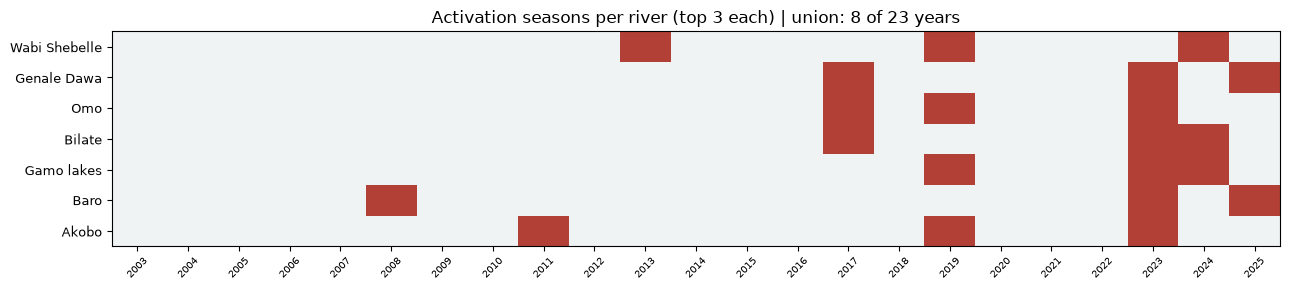

In [6]:
fig, ax = plt.subplots(figsize=(13, 3.0))
mat = active[RIVERS].T.values.astype(int)
ax.imshow(mat, cmap=mcolors.ListedColormap(["#f0f3f3", "#B34036"]), aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(N_YEARS)); ax.set_xticklabels(YEARS, fontsize=7, rotation=45)
ax.set_yticks(range(len(RIVERS))); ax.set_yticklabels(RIVERS, fontsize=9)
ax.set_title(f"Activation seasons per river (top 3 each) | union: {len(union_years)} of {N_YEARS} years")
plt.tight_layout(); plt.show()

## Impact record, year by year: FloodScan, EM-DAT, CERF

- FloodScan: OND flood events in the Somali-region riverine zones (satellite;
  the extract for the new zones is not built yet and is a named gap).
- EM-DAT: flood events whose recorded locations name the riverine areas and
  whose dates touch OND. The blob snapshot is refreshed manually.
- CERF: allocations to Ethiopia with emergency type flood, by year (national).

In [7]:
from ocha_stratus import emdat
import requests

AREA_WORDS = [
    "somali", "gode", "shabelle", "shebelle", "shabele", "kelafo", "mustahil",
    "ferfer", "afder", "liben", "liban", "dolo", "genale", "dawa", "imi", "chereti",
    "omo", "dasenech", "gnangatom", "hamer", "gambel", "itang", "baro", "akobo",
    "nuer", "arba minch", "gamo", "bilate", "loka abaya",
]

fs_events = stratus.load_parquet_from_blob(
    f"{PROJECT_PREFIX}/processed/floodscan/floodscan_event_catalogue.parquet", stage=STAGE
)
fs_events["peak_date"] = pd.to_datetime(fs_events["peak_date"])
fs_ond = fs_events[fs_events["season"] == "deyr"]
fs_years = {rp: sorted(fs_ond[fs_ond["fs_rp"] == rp]["peak_date"].dt.year.unique()) for rp in [2, 3]}

em = emdat.load_emdat_from_blob("ETH", include_historic=True, stage=STAGE)
em.columns = [c.lower().replace(" ", "_") for c in em.columns]
flood = em[em["disaster_type"].str.contains("Flood", case=False, na=False)].copy()
id_col = next(c for c in flood.columns if c.startswith("disno"))
loc_text = (
    flood["location"].fillna("") + " " + flood["admin_units"].fillna("").astype(str)
    + " " + flood["river_basin"].fillna("")
).str.lower()
flood["area_hit"] = loc_text.apply(lambda s: any(w in s for w in AREA_WORDS))
def touches_ond(r):
    sm = r.get("start_month"); em_ = r.get("end_month") or sm
    if pd.isna(sm):
        return False
    sm, em_ = int(sm), int(em_ if not pd.isna(em_) else sm)
    months, mth = set(), sm
    while True:
        months.add(mth)
        if mth == em_ or len(months) > 12: break
        mth = mth % 12 + 1
    return bool(months & set(OND))
flood["ond"] = flood.apply(touches_ond, axis=1)
em_ond = flood[flood["area_hit"] & flood["ond"] & flood["start_year"].between(2003, 2025)]
emdat_by_year = em_ond.groupby("start_year").agg(
    emdat_events=(id_col, "count"), emdat_affected=("total_affected", "sum")
)

cerf_raw = requests.get("https://cerfgms-webapi.unocha.org/v1/application/All.json", timeout=300).json()
apps = pd.json_normalize(cerf_raw["application"] if "application" in cerf_raw else cerf_raw)
apps.columns = [c.lower() for c in apps.columns]
eth = apps[apps.get("countryname", pd.Series(dtype=str)).str.contains("Ethiopia", case=False, na=False)]
fl = eth[eth.filter(like="emergency").apply(
    lambda col: col.astype(str).str.contains("flood", case=False, na=False)
).any(axis=1)].copy()
year_col = next(c for c in ["year", "allocationyear", "applicationyear"] if c in fl.columns)
amount_col = next(c for c in ["totalamountapproved", "amountapproved", "totalamount"] if c in fl.columns)
cerf_by_year = fl[fl[year_col].astype(int).between(2003, 2025)].groupby(fl[year_col].astype(int)).agg(
    cerf_allocations=(amount_col, "count"), cerf_usd=(amount_col, "sum"),
)

impact = pd.DataFrame(index=YEARS)
impact["trigger"] = [y in set(union_years) for y in YEARS]
impact["floodscan_rp2_somali"] = [y in set(fs_years[2]) for y in YEARS]
impact["floodscan_rp3_somali"] = [y in set(fs_years[3]) for y in YEARS]
impact = impact.join(emdat_by_year).join(cerf_by_year)
impact["emdat_events"] = impact["emdat_events"].fillna(0).astype(int)
impact["cerf_allocations"] = impact["cerf_allocations"].fillna(0).astype(int)
impact["cerf_usd"] = impact["cerf_usd"].fillna(0).round(0)
caught = impact[impact["trigger"]]
print(f"EM-DAT OND flood years caught: {int((caught['emdat_events'] > 0).sum())} of {int((impact['emdat_events'] > 0).sum())}")
print(f"CERF flood years caught: {int((caught['cerf_allocations'] > 0).sum())} of {int((impact['cerf_allocations'] > 0).sum())}")
impact

EM-DAT OND flood years caught: 4 of 8
CERF flood years caught: 1 of 4


,trigger,floodscan_rp2_somali,floodscan_rp3_somali,emdat_events,emdat_affected,cerf_allocations,cerf_usd
2003,False,False,False,0,NaN,0,0.0
2004,False,True,True,0,NaN,0,0.0
2005,False,False,False,0,NaN,0,0.0
2006,False,True,True,1,361600.0,2,4994747.0
2007,False,True,True,1,239586.0,0,0.0
2008,True,True,False,1,23831.0,0,0.0
2009,False,True,True,0,NaN,0,0.0
2010,False,False,False,0,NaN,0,0.0
2011,True,True,True,1,40200.0,0,0.0
2012,False,False,False,0,NaN,0,0.0


## Save

In [8]:
out_levels = levels.reset_index()
stratus.upload_csv_to_blob(
    out_levels, f"{PROJECT_PREFIX}/processed/glofas/ond_trigger_levels.csv", stage=STAGE
)
stratus.upload_parquet_to_blob(
    act_table.reset_index(names="year"),
    f"{PROJECT_PREFIX}/processed/comparison/ond_trigger_activations.parquet", stage=STAGE
)
stratus.upload_parquet_to_blob(
    impact.reset_index(names="year"),
    f"{PROJECT_PREFIX}/processed/comparison/ond_impact_record.parquet", stage=STAGE
)
print("saved levels, activations and impact record")

saved levels, activations and impact record
